In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import (
    shapiro,
    normaltest,
    ttest_1samp,
    ttest_ind,
    ttest_rel,
    f_oneway,
    chi2_contingency
)


In [ ]:
# Generate e-commerce data set

n = 5000

customer_id = np.arange(1, n + 1)

age = np.random.normal(loc=38, scale=12, size=n).astype(int)
age = np.clip(age, 18, 70)

gender = np.random.choice(["Male", "Female"], size=n, p=[0.52, 0.48])

country = np.random.choice(
    ["USA", "India", "UK", "Canada", "Germany"],
    size=n,
    p=[0.45, 0.25, 0.12, 0.10, 0.08]
)

customer_segment = np.random.choice(
    ["New", "Regular", "Premium", "VIP"],
    size=n,
    p=[0.35, 0.40, 0.20, 0.05]
)

campaign = np.random.choice(
    ["Campaign_A", "Campaign_B"],
    size=n,
    p=[0.50, 0.50]
)

visit_frequency = np.random.poisson(lam=6, size=n)
visit_frequency = np.clip(visit_frequency, 1, 25)

discount = np.random.normal(loc=12, scale=6, size=n)
discount = np.clip(discount, 0, 40)

segment_effect = {
    "New": 20,
    "Regular": 45,
    "Premium": 90,
    "VIP": 180
}

campaign_effect = {
    "Campaign_A": 0,
    "Campaign_B": 12
}

base_purchase = []

for i in range(n):
    value = (
        25
        + age[i] * 0.8
        + visit_frequency[i] * 6
        + discount[i] * 1.5
        + segment_effect[customer_segment[i]]
        + campaign_effect[campaign[i]]
        + np.random.normal(0, 35)
    )
    base_purchase.append(value)

purchase_amount = np.array(base_purchase)


purchase_amount = np.exp(np.log(np.maximum(purchase_amount, 5)) + np.random.normal(0, 0.35, n))
purchase_amount = np.round(purchase_amount, 2)

quantity = np.random.poisson(lam=3, size=n)
quantity = np.clip(quantity, 1, 15)


return_probability = 0.05 + (discount / 100) + np.where(customer_segment == "New", 0.04, 0)
returned = np.random.binomial(1, np.clip(return_probability, 0, 0.45))


churn_probability = (
    0.35
    - visit_frequency * 0.015
    - np.log1p(purchase_amount) * 0.025
    + np.where(customer_segment == "New", 0.10, 0)
)
churn_probability = np.clip(churn_probability, 0.02, 0.65)
churned = np.random.binomial(1, churn_probability)

df = pd.DataFrame({
    "CustomerID": customer_id,
    "Age": age,
    "Gender": gender,
    "Country": country,
    "CustomerSegment": customer_segment,
    "Campaign": campaign,
    "VisitFrequency": visit_frequency,
    "Discount": np.round(discount, 2),
    "Quantity": quantity,
    "PurchaseAmount": purchase_amount,
    "Returned": returned,
    "Churned": churned
})

print("Dataset shape:", df.shape)
print(df.head())


Dataset shape: (5000, 12)
   CustomerID  Age  Gender Country CustomerSegment    Campaign  \
0           1   39    Male     USA             New  Campaign_A   
1           2   24  Female     USA             New  Campaign_A   
2           3   50    Male     USA         Regular  Campaign_A   
3           4   27  Female  Canada             New  Campaign_A   
4           5   42    Male   India         Regular  Campaign_A   

   VisitFrequency  Discount  Quantity  PurchaseAmount  Returned  Churned  
0               5     12.00         1          121.88         0        0  
1               6      0.00         4           47.60         0        0  
2               4     15.74         3          110.48         0        0  
3               5      5.72         2           45.75         0        0  
4               1     15.45         4          136.71         0        0  


In [6]:
# Data Overview and Cleaning

print("\nData Info:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nBasic description:")
print(df.describe())



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       5000 non-null   int64  
 1   Age              5000 non-null   int64  
 2   Gender           5000 non-null   object 
 3   Country          5000 non-null   object 
 4   CustomerSegment  5000 non-null   object 
 5   Campaign         5000 non-null   object 
 6   VisitFrequency   5000 non-null   int32  
 7   Discount         5000 non-null   float64
 8   Quantity         5000 non-null   int32  
 9   PurchaseAmount   5000 non-null   float64
 10  Returned         5000 non-null   int32  
 11  Churned          5000 non-null   int32  
dtypes: float64(2), int32(4), int64(2), object(4)
memory usage: 390.8+ KB
None

Missing values:
CustomerID         0
Age                0
Gender             0
Country            0
CustomerSegment    0
Campaign           0
VisitFrequency 

In [7]:
# Descriptive statistics


numeric_cols = ["Age", "VisitFrequency", "Discount", "Quantity", "PurchaseAmount"]

desc_stats = df[numeric_cols].agg([
    "mean",
    "median",
    "std",
    "var",
    "min",
    "max",
    "skew",
    "kurt"
]).T

desc_stats["range"] = df[numeric_cols].max() - df[numeric_cols].min()
desc_stats["IQR"] = df[numeric_cols].quantile(0.75) - df[numeric_cols].quantile(0.25)

print("\nDescriptive Statistics:")
print(desc_stats)



Descriptive Statistics:
                      mean  median        std          var   min     max  \
Age              37.743600   38.00  11.349768   128.817222  18.0   70.00   
VisitFrequency    5.963800    6.00   2.377061     5.650420   1.0   17.00   
Discount         12.066206   11.87   5.946680    35.362999   0.0   33.20   
Quantity          3.074600    3.00   1.657946     2.748785   1.0   12.00   
PurchaseAmount  175.853940  157.62  88.167124  7773.441782   3.1  770.46   

                    skew      kurt   range       IQR  
Age             0.188973 -0.429362   52.00   16.0000  
VisitFrequency  0.440916  0.240949   16.00    3.0000  
Discount        0.155055 -0.263117   33.20    8.2300  
Quantity        0.744375  0.381831   11.00    2.0000  
PurchaseAmount  1.322292  2.809317  767.36  104.4225  


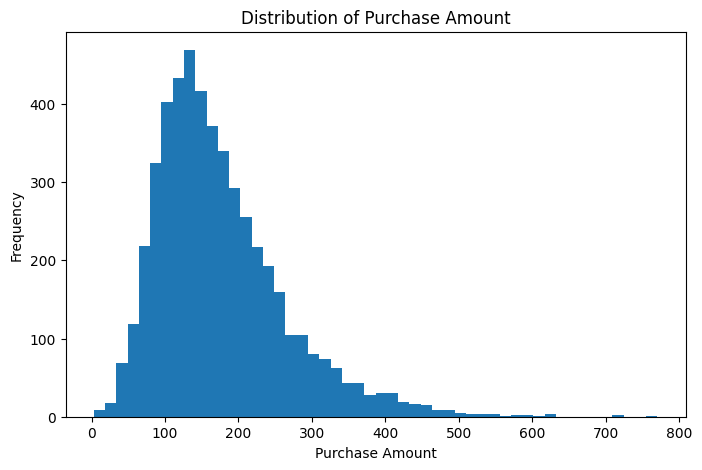

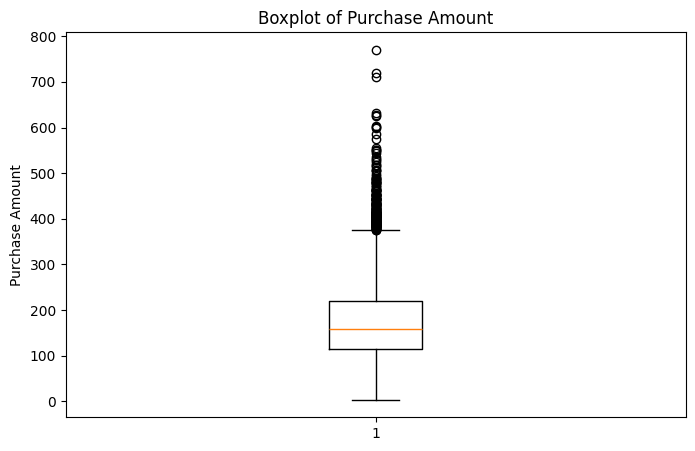

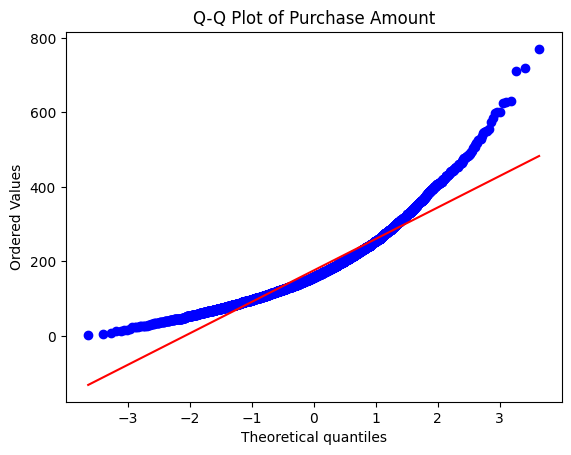

In [11]:
# Distribution analysis


plt.figure(figsize=(8, 5))
plt.hist(df["PurchaseAmount"], bins=50)
plt.title("Distribution of Purchase Amount")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 5))
plt.boxplot(df["PurchaseAmount"])
plt.title("Boxplot of Purchase Amount")
plt.ylabel("Purchase Amount")
plt.show()

stats.probplot(df["PurchaseAmount"], dist="norm", plot=plt)
plt.title("Q-Q Plot of Purchase Amount")
plt.show()


In [13]:
# Normality tests


sample_purchase = df["PurchaseAmount"].sample(500, random_state=42)

shapiro_stat, shapiro_p = shapiro(sample_purchase)
normaltest_stat, normaltest_p = normaltest(sample_purchase)

print("\nNormality Tests for Purchase Amount:")
print("Shapiro-Wilk statistic:", shapiro_stat)
print("Shapiro-Wilk p-value:", shapiro_p)
print("D'Agostino statistic:", normaltest_stat)
print("D'Agostino p-value:", normaltest_p)

if shapiro_p < 0.05:
    print("Conclusion: PurchaseAmount is not normally distributed.")
else:
    print("Conclusion: PurchaseAmount looks approximately normal.")


Normality Tests for Purchase Amount:
Shapiro-Wilk statistic: 0.8890368840036862
Shapiro-Wilk p-value: 1.6414461406466986e-18
D'Agostino statistic: 191.7212861184538
D'Agostino p-value: 2.33481076853222e-42
Conclusion: PurchaseAmount is not normally distributed.


In [14]:
# Outlier detection using IQR


Q1 = df["PurchaseAmount"].quantile(0.25)
Q3 = df["PurchaseAmount"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[
    (df["PurchaseAmount"] < lower_bound) |
    (df["PurchaseAmount"] > upper_bound)
]

print("\nIQR Outlier Detection:")
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", len(outliers_iqr))

print("\nTop 10 high-value customers:")
print(df.sort_values("PurchaseAmount", ascending=False).head(10))


IQR Outlier Detection:
Lower bound: -42.066250000000025
Upper bound: 375.62375000000003
Number of outliers: 175

Top 10 high-value customers:
      CustomerID  Age  Gender Country CustomerSegment    Campaign  \
1578        1579   32    Male      UK         Premium  Campaign_B   
4131        4132   46  Female     USA             VIP  Campaign_B   
2364        2365   39    Male   India         Regular  Campaign_A   
4264        4265   42  Female     USA         Premium  Campaign_A   
3077        3078   52    Male     USA             VIP  Campaign_B   
869          870   48  Female     USA             VIP  Campaign_B   
43            44   26    Male     USA         Premium  Campaign_B   
3444        3445   69    Male     USA             VIP  Campaign_B   
3825        3826   48  Female   India             VIP  Campaign_A   
2343        2344   18    Male     USA             VIP  Campaign_A   

      VisitFrequency  Discount  Quantity  PurchaseAmount  Returned  Churned  
1578               

In [15]:
# Z-score and standardization


df["Purchase_Zscore"] = stats.zscore(df["PurchaseAmount"])

z_outliers = df[np.abs(df["Purchase_Zscore"]) > 3]

print("\nZ-score Outlier Detection:")
print("Number of z-score outliers:", len(z_outliers))
print(z_outliers[["CustomerID", "PurchaseAmount", "Purchase_Zscore"]].head())



Z-score Outlier Detection:
Number of z-score outliers: 69
     CustomerID  PurchaseAmount  Purchase_Zscore
43           44          602.35         4.837843
321         322          453.81         3.152920
495         496          484.31         3.498888
525         526          463.25         3.260000
577         578          477.92         3.426405


In [16]:
# Probability and conditional probability


p_spend_100 = np.mean(df["PurchaseAmount"] > 100)
p_returned = np.mean(df["Returned"] == 1)
p_return_given_discount = np.mean(df[df["Discount"] > 20]["Returned"] == 1)
p_churn_premium = np.mean(df[df["CustomerSegment"] == "Premium"]["Churned"] == 1)

print("\nProbability Analysis:")
print("P(PurchaseAmount > 100):", p_spend_100)
print("P(Returned):", p_returned)
print("P(Returned | Discount > 20%):", p_return_given_discount)
print("P(Churned | Premium customer):", p_churn_premium)


Probability Analysis:
P(PurchaseAmount > 100): 0.8274
P(Returned): 0.1888
P(Returned | Discount > 20%): 0.31896551724137934
P(Churned | Premium customer): 0.14575289575289574


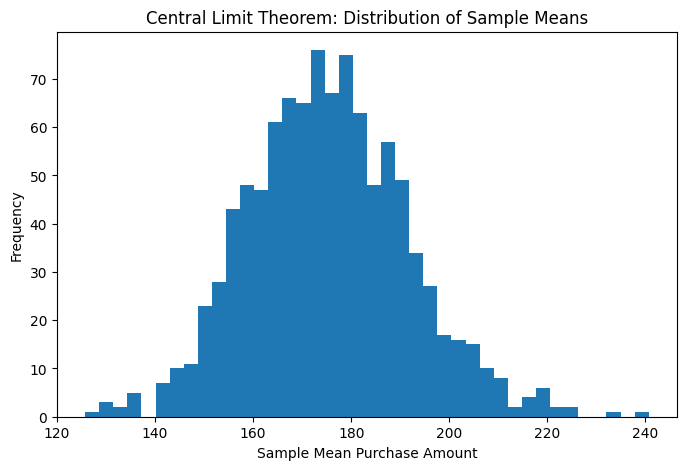


CLT Analysis:
Original mean: 175.85394
Mean of sample means: 175.29926033333334
Standard deviation of sample means: 16.369244631927682


In [17]:
# Central Limit Theorem


sample_means = []

for i in range(1000):
    sample = df["PurchaseAmount"].sample(30, replace=True)
    sample_means.append(sample.mean())

plt.figure(figsize=(8, 5))
plt.hist(sample_means, bins=40)
plt.title("Central Limit Theorem: Distribution of Sample Means")
plt.xlabel("Sample Mean Purchase Amount")
plt.ylabel("Frequency")
plt.show()

print("\nCLT Analysis:")
print("Original mean:", df["PurchaseAmount"].mean())
print("Mean of sample means:", np.mean(sample_means))
print("Standard deviation of sample means:", np.std(sample_means))


In [18]:
# Confidence interval for average purchase amount


mean_purchase = df["PurchaseAmount"].mean()
std_purchase = df["PurchaseAmount"].std()
n_obs = len(df)

confidence_level = 0.95
alpha = 1 - confidence_level

t_critical = stats.t.ppf(1 - alpha / 2, df=n_obs - 1)
margin_error = t_critical * (std_purchase / np.sqrt(n_obs))

ci_lower = mean_purchase - margin_error
ci_upper = mean_purchase + margin_error

print("\n95% Confidence Interval for Average Purchase Amount:")
print("Mean:", mean_purchase)
print("CI Lower:", ci_lower)
print("CI Upper:", ci_upper)



95% Confidence Interval for Average Purchase Amount:
Mean: 175.85394
CI Lower: 173.40952506628494
CI Upper: 178.29835493371505


In [19]:
# One-sample t-test
# Business question:
# Is average spending significantly greater than $150?


test_value = 150

t_stat, p_value_two_sided = ttest_1samp(df["PurchaseAmount"], popmean=test_value)

# Convert to one-sided test
if t_stat > 0:
    p_value_one_sided = p_value_two_sided / 2
else:
    p_value_one_sided = 1 - (p_value_two_sided / 2)

print("\nOne-Sample T-Test:")
print("H0: Mean PurchaseAmount = 150")
print("H1: Mean PurchaseAmount > 150")
print("t-statistic:", t_stat)
print("one-sided p-value:", p_value_one_sided)

if p_value_one_sided < 0.05:
    print("Conclusion: Average purchase amount is significantly greater than 150.")
else:
    print("Conclusion: Not enough evidence that average purchase amount is greater than 150.")



One-Sample T-Test:
H0: Mean PurchaseAmount = 150
H1: Mean PurchaseAmount > 150
t-statistic: 20.735048884452958
one-sided p-value: 5.480221681645963e-92
Conclusion: Average purchase amount is significantly greater than 150.


In [ ]:
# Two-sample t-test
# Premium vs Regular customers


premium_purchase = df[df["CustomerSegment"] == "Premium"]["PurchaseAmount"]
regular_purchase = df[df["CustomerSegment"] == "Regular"]["PurchaseAmount"]

t_stat, p_value = ttest_ind(premium_purchase, regular_purchase, equal_var=False)

print("\nIndependent Two-Sample T-Test:")
print("H0: Premium and Regular customers have same average spending")
print("H1: Premium and Regular customers have different average spending")
print("t-statistic:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Conclusion: Premium and Regular customers spend significantly differently.")
else:
    print("Conclusion: No significant difference found.")



Independent Two-Sample T-Test:
H0: Premium and Regular customers have same average spending
H1: Premium and Regular customers have different average spending
t-statistic: 13.746942122720773
p-value: 5.195223034145795e-41
Conclusion: Premium and Regular customers spend significantly differently.


In [21]:
# Paired t-test
# Before and after campaign spending


paired_sample = df.sample(500, random_state=42).copy()

paired_sample["BeforeCampaignSpend"] = paired_sample["PurchaseAmount"] - np.random.normal(10, 25, size=500)
paired_sample["AfterCampaignSpend"] = paired_sample["PurchaseAmount"]

t_stat, p_value = ttest_rel(
    paired_sample["AfterCampaignSpend"],
    paired_sample["BeforeCampaignSpend"]
)

print("\nPaired T-Test:")
print("H0: No difference before and after campaign")
print("H1: Spending changed after campaign")
print("t-statistic:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Conclusion: Spending changed significantly after the campaign.")
else:
    print("Conclusion: No significant spending change found.")




Paired T-Test:
H0: No difference before and after campaign
H1: Spending changed after campaign
t-statistic: 9.726184599349887
p-value: 1.3696858524545077e-20
Conclusion: Spending changed significantly after the campaign.
